In [1]:
from google.colab import files
import io

uploaded = files.upload()

import pandas as pd
import numpy as np
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

df = pd.read_csv(io.BytesIO(uploaded['malicious_phish.csv']))
print(df.shape)
print(df.head())
print(df['type'].value_counts())

Saving malicious_phish.csv to malicious_phish.csv
(651191, 2)
                                                 url        type
0                                   br-icloud.com.br    phishing
1                mp3raid.com/music/krizz_kaliko.html      benign
2                    bopsecrets.org/rexroth/cr/1.htm      benign
3  http://www.garage-pirenne.be/index.php?option=...  defacement
4  http://adventure-nicaragua.net/index.php?optio...  defacement
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64


In [2]:
import pandas as pd
import numpy as np
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

df = pd.read_csv('malicious_phish.csv')
print(df.shape)
print(df.head())
print(df['type'].value_counts())

(651191, 2)
                                                 url        type
0                                   br-icloud.com.br    phishing
1                mp3raid.com/music/krizz_kaliko.html      benign
2                    bopsecrets.org/rexroth/cr/1.htm      benign
3  http://www.garage-pirenne.be/index.php?option=...  defacement
4  http://adventure-nicaragua.net/index.php?optio...  defacement
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64


In [3]:
# Feature extraction
import re
from urllib.parse import urlparse

def extract_features(url):
    """Extract security-relevant features from a URL string."""
    parsed = urlparse(url)

    # Basic length features
    url_length = len(url)
    hostname_length = len(parsed.netloc)
    path_length = len(parsed.path)

    # Special character counts
    num_dots = url.count('.')
    num_hyphens = url.count('-')
    num_underscores = url.count('_')
    num_slashes = url.count('/')
    num_at = url.count('@')          # @ in URL = redirect trick
    num_question = url.count('?')
    num_equals = url.count('=')
    num_ampersand = url.count('&')
    num_percent = url.count('%')     # URL encoding = often obfuscation
    num_digits = sum(c.isdigit() for c in url)

    # Structural features
    has_ip = 1 if re.search(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', url) else 0
    has_https = 1 if url.startswith('https') else 0
    subdomain_count = len(parsed.netloc.split('.')) - 2
    subdomain_count = max(0, subdomain_count)

    # Entropy
    def entropy(s):
        if len(s) == 0:
            return 0
        probs = [s.count(c) / len(s) for c in set(s)]
        return -sum(p * np.log2(p) for p in probs)

    url_entropy = entropy(url)

    # Suspicious keyword presence
    suspicious_words = ['login', 'signin', 'account', 'secure', 'update',
                        'verify', 'confirm', 'banking', 'paypal', 'free',
                        'click', 'download', 'install', 'exe', 'zip']
    has_suspicious = 1 if any(w in url.lower() for w in suspicious_words) else 0

    return [
        url_length, hostname_length, path_length,
        num_dots, num_hyphens, num_underscores, num_slashes,
        num_at, num_question, num_equals, num_ampersand, num_percent,
        num_digits, has_ip, has_https, subdomain_count,
        url_entropy, has_suspicious
    ]

FEATURE_NAMES = [
    'url_length', 'hostname_length', 'path_length',
    'num_dots', 'num_hyphens', 'num_underscores', 'num_slashes',
    'num_at', 'num_question', 'num_equals', 'num_ampersand', 'num_percent',
    'num_digits', 'has_ip', 'has_https', 'subdomain_count',
    'url_entropy', 'has_suspicious'
]

# Apply to all rows
print("Extracting features... (takes ~2 min)")
X_raw = df['url'].apply(extract_features).tolist()
X = np.array(X_raw)
print(f"Feature matrix shape: {X.shape}")

Extracting features... (takes ~2 min)
Feature matrix shape: (651191, 18)


In [4]:
#Train/val/test split + train model
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score
import time

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['type'])
print("Classes:", le.classes_)  # ['benign' 'defacement' 'malware' 'phishing']

# Split: 80% train, 10% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# scaler + logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        random_state=SEED,
        max_iter=1000,
        class_weight='balanced'  # handles class imbalance
    ))
])

# Hyperparameter search over C
param_grid = {'clf__C': [0.01, 0.1, 1.0, 10.0]}

print("Running GridSearchCV... (takes ~5 min)")
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search.fit(X_train, y_train)
train_time = time.time() - start

print(f"\nBest C: {grid_search.best_params_}")
print(f"Best CV F1 (macro): {grid_search.best_score_:.4f}")
print(f"Training time: {train_time:.1f}s")

# Evaluate on validation set
best_model = grid_search.best_estimator_
y_val_pred = best_model.predict(X_val)
val_f1 = f1_score(y_val, y_val_pred, average='macro')

print(f"\n=== VALIDATION RESULTS ===")
print(f"Macro F1: {val_f1:.4f}")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))



Classes: ['benign' 'defacement' 'malware' 'phishing']
Train: 520952, Val: 65119, Test: 65120
Running GridSearchCV... (takes ~5 min)
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best C: {'clf__C': 1.0}
Best CV F1 (macro): 0.7010
Training time: 137.9s

=== VALIDATION RESULTS ===
Macro F1: 0.7002
              precision    recall  f1-score   support

      benign       0.94      0.74      0.83     42810
  defacement       0.80      0.91      0.85      9646
     malware       0.59      0.78      0.67      3252
    phishing       0.36      0.61      0.45      9411

    accuracy                           0.75     65119
   macro avg       0.67      0.76      0.70     65119
weighted avg       0.82      0.75      0.77     65119



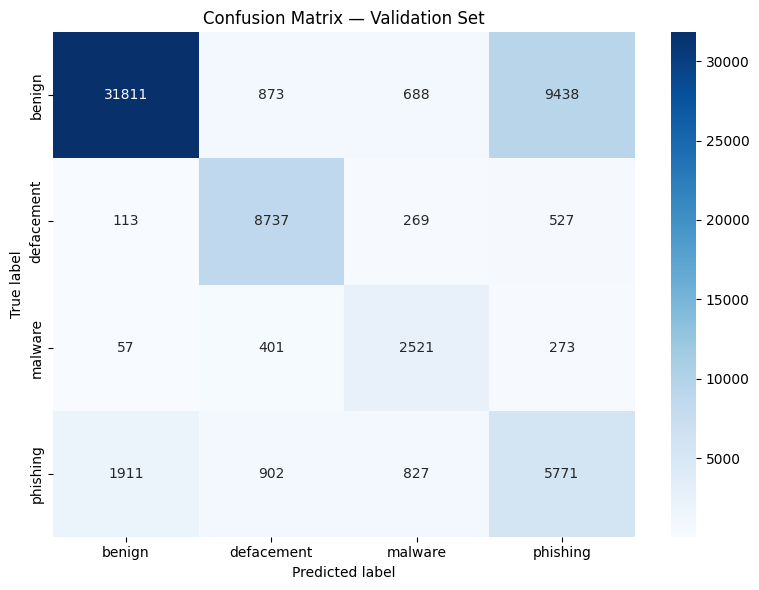


Total misclassified: 16279

=== FAILURE EXAMPLES ===

Example 1:
  URL:       https://grandbettinggir.blogspot.com/
  True:      benign
  Predicted: phishing

Example 2:
  URL:       http://088celtabet.com
  True:      defacement
  Predicted: benign

Example 3:
  URL:       https://safirbet894.com/
  True:      phishing
  Predicted: defacement

Example 4:
  URL:       http://safirbetgirisadresimiz.blogspot.com
  True:      phishing
  Predicted: benign

Example 5:
  URL:       http://vevobahisgirissitemiz.blogspot.com
  True:      benign
  Predicted: phishing


In [5]:
# Confusion matrix + error analysis
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues')
plt.title('Confusion Matrix — Validation Set')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# misclassified examples
misclassified_idx = np.where(y_val_pred != y_val)[0]
print(f"\nTotal misclassified: {len(misclassified_idx)}")

# 5 failure examples with their features
val_urls = df['url'].iloc[
    X_train.shape[0] + misclassified_idx[:5]
].values

print("\n=== FAILURE EXAMPLES ===")
for i, idx in enumerate(misclassified_idx[:5]):
    true_label = le.classes_[y_val[idx]]
    pred_label = le.classes_[y_val_pred[idx]]
    url = df['url'].iloc[len(X_train) + idx]
    print(f"\nExample {i+1}:")
    print(f"  URL:       {url}")
    print(f"  True:      {true_label}")
    print(f"  Predicted: {pred_label}")



In [6]:
import joblib

joblib.dump(best_model, 'model.joblib')
joblib.dump(le, 'label_encoder.joblib')
print("Model saved as model.joblib")

loaded_model = joblib.load('model.joblib')
loaded_le = joblib.load('label_encoder.joblib')

test_url = "http://paypal-secure-login.xyz/account/verify"
test_features = np.array([extract_features(test_url)])
pred = loaded_model.predict(test_features)
print(f"Test prediction for '{test_url}': {loaded_le.classes_[pred[0]]}")

from google.colab import files
files.download('model.joblib')
files.download('label_encoder.joblib')
files.download('confusion_matrix.png')

Model saved as model.joblib
Test prediction for 'http://paypal-secure-login.xyz/account/verify': malware


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>